# 01 — Logistic Regression (Baseline-Modell)

**Was dieses Notebook tut:** Es trainiert das einfachste sinnvolle Modell für die Frage
*"Wird diese Buchung storniert?"* und legt damit die Messlatte, die jedes komplexere
Modell (XGBoost, HistGB, Survival-Modelle) schlagen muss.

**Workflow in diesem Notebook** (so arbeitet ein ML Engineer):

1. Daten laden (sauberes Parquet aus Notebook 00 — dort ist alles Cleaning passiert)
2. Features auswählen (welche Spalten darf das Modell sehen?)
3. Zeitlicher Split: train (alt) / val (mittel) / test (neu) — kommt fertig aus 00
4. Preprocessing-Pipeline (Lücken füllen, skalieren, Kategorien in Zahlen übersetzen)
5. Modell definieren (LogReg + Kalibrierung, damit Wahrscheinlichkeiten "ehrlich" sind)
6. Cross-Validation auf Train (wie stabil ist das Modell?)
7. Fit auf Train → Metriken auf **Val**
8. Threshold-Tuning auf **Val** (ab welcher Wahrscheinlichkeit sagen wir "wird storniert"?)
9. Finaler Lauf auf **Test** — genau EINMAL, das ist die ehrliche Zahl
10. Slice-Analyse (wo ist das Modell gut/schlecht? pro Hotel, Kanal, Lead-Time)
11. XAI: Warum entscheidet das Modell so? (Koeffizienten, Permutation, PDP, SHAP)
12. Alles speichern (Modell, Predictions, Model Card) für App + Vergleichs-Notebook

> **Die eiserne Regel:** Das Test-Set wird für KEINE Entscheidung benutzt.
> Tuning & Modellwahl passieren auf Train/Val. Test liefert nur am Ende die ehrliche Zahl.


In [6]:
# =============================================================================
# §0 SETUP — Imports, Projekt-Pfade, Plot-Stil
# =============================================================================
# "from __future__ import annotations": moderne Typ-Schreibweise, reine Formsache.
from __future__ import annotations

# Standardbibliothek: sys (Pfade), json (Model Card speichern), warnings (Spam aus).
import sys, json, warnings
# Path = komfortabler Umgang mit Dateipfaden (besser als Strings zusammenkleben).
from pathlib import Path

# Projekt-Root finden: wir laufen von notebooks/ aus, also so lange nach oben
# gehen, bis wir die Datei pyproject.toml sehen — das ist die Projektwurzel.
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    _here = _here.parent
# Projektwurzel in den Python-Suchpfad legen, damit "from src import ..." klappt.
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

# Die drei Arbeitspferde: numpy (Mathe), pandas (Tabellen), matplotlib (Plots).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Unsere kleinen Projekt-Helfer (bewusst minimal gehalten):
#   load_clean_reservations = lädt das von 00 erzeugte saubere Parquet
#   apply_stayery_style / color = Stayery-Branding für Plots
#   figures_dir / tables_dir = wohin Ergebnisse gespeichert werden
from src import (apply_stayery_style, color, load_clean_reservations,
                 figures_dir, tables_dir)

# FutureWarnings stummschalten (Bibliotheks-Rauschen, keine echten Probleme).
warnings.filterwarnings("ignore", category=FutureWarning)
# Stayery-Look für alle folgenden Plots aktivieren.
apply_stayery_style()
# Pandas soll breite Tabellen vollständig anzeigen statt abzuschneiden.
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

# Output-Ordner für dieses Notebook anlegen (existieren sie schon: kein Fehler).
FIG = figures_dir() / "01_logreg";  FIG.mkdir(parents=True, exist_ok=True)
TAB = tables_dir()  / "01_logreg";  TAB.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# SCHALTER: FAST_DEV = True  → kleiner Datenausschnitt + weniger CV-Folds.
# Zum schnellen Ausprobieren/Ändern. Für echte Ergebnisse: False (Volllauf).
# -----------------------------------------------------------------------------
FAST_DEV = False
# Ein fester Zufalls-Seed macht alles reproduzierbar (gleicher Lauf = gleiche Zahlen).
SEED = 42

print(f"Setup ok. Projekt: {_here.name} | FAST_DEV={FAST_DEV}")

Setup ok. Projekt: OverbookingAnalyse | FAST_DEV=False


## §1 — Daten laden

Wir laden **nur** das fertige, saubere Parquet aus Notebook 00. Alles Cleaning
(Duplikate, Ausreißer, COVID-Floor 2022-08, Leakage-Spalten raus) ist dort passiert
und dokumentiert. Dieses Notebook fasst die Rohdaten nie an — eine Quelle der Wahrheit.

Das Zielfeld heißt `status` und ist bereits binär: **1 = storniert, 0 = angereist**
(NoShows wurden in 00 ausgeschlossen).

In [7]:
# =============================================================================
# §1 DATEN LADEN
# =============================================================================
# Das saubere Parquet laden (wirft einen verständlichen Fehler, falls 00 nie lief).
df = load_clean_reservations()

# Das Zielfeld umbenennen: "status" ist als Name zu unspezifisch. Ab hier heißt
# es überall is_cancelled (1 = storniert, 0 = angereist) — eindeutig lesbar.
df = df.rename(columns={"status": "is_cancelled"})

# FAST_DEV-Modus: nur jede 5. Zeile behalten (zeitlich gleichmäßig verteilt).
if FAST_DEV:
    df = df.iloc[::5].copy()

# Kontrollausdruck: Wie viele Buchungen, welcher Zeitraum, wie viel Storno?
print(f"{len(df):,} Buchungen | Anreisen {df['arrival'].min().date()} .. {df['arrival'].max().date()}")
print(f"Storno-Quote gesamt: {df['is_cancelled'].mean():.1%}")
# Die ersten 3 Zeilen ansehen — schneller Plausibilitäts-Blick auf die Daten.
df.head(3)

169,617 Buchungen | Anreisen 2022-08-01 .. 2026-06-07
Storno-Quote gesamt: 20.7%


,is_cancelled,travelPurpose,property_name,unitGroup_name,channelCode,primaryGuest_preferredLanguage,primaryGuest_address_countryCode,guaranteeType,cancellationFee_name,arrival,departure,created,lead_time_days,los_nights,gross_amount,gross_per_night,company_name_clean,ratePlan_type,ratePlan_category,has_group,diff_gross_cancellation_fee,adults_n,has_promo,has_corporate_code,has_children,guest_country_region,arrival_dow,arrival_month,is_weekend_arrival,stay_bucket,log_gross_amount,has_company,company_prior_bookings,company_prior_cancel_rate,is_repeat_company,temporal_split,is_temporal_test,is_temporal_val
0,1,Leisure,Bochum Ehrenfeld,BIG,Airbnb,NaN,NaN,CreditCard,Airbnb,2026-06-07 13:00:00+00:00,2026-06-08 09:00:00+00:00,2026-06-07 11:44:42+00:00,0.052292,1,68.99,68.99,NaN,flexible,airbnb shortstay,0,0.0,1,0,0,0,Unknown,6,6,1,short,4.248352,0,0,<NA>,0,test,1,0
1,1,Leisure,Bochum Ehrenfeld,BIGGER,Airbnb,NaN,NaN,CreditCard,Airbnb,2026-05-09 13:00:00+00:00,2026-05-10 09:00:00+00:00,2026-05-07 21:08:58+00:00,1.660440,1,130.99,130.99,NaN,flexible,airbnb shortstay,0,0.0,2,0,0,0,Unknown,5,5,1,short,4.882726,0,0,<NA>,0,test,1,0
2,1,NaN,Bochum Ehrenfeld,BIG,Direct,NaN,NaN,CreditCard,Flexible,2025-09-24 13:00:00+00:00,2025-09-25 09:00:00+00:00,2025-09-24 06:00:25+00:00,0.291377,1,12.00,12.0,BD Apartment GmbH,comp,comp,0,12.0,1,1,0,0,Unknown,2,9,0,short,2.564949,1,29,0.551724,1,val,0,1


## §2 — Feature-Auswahl (was darf das Modell sehen?)

Drei Gruppen:

| Gruppe | Behandlung | Warum |
|---|---|---|
| **Numerisch** | Lücken mit Median füllen → standardisieren | LogReg braucht vergleichbare Skalen |
| **Numerisch (History)** | Lücken mit **0** füllen → standardisieren | `company_prior_cancel_rate` ist leer, wenn die Firma keine Vorbuchungen hat — "keine Historie" ist eine echte 0-Information, kein Messfehler |
| **Kategorisch** | Lücken mit häufigstem Wert füllen → One-Hot (eine 0/1-Spalte pro Ausprägung) | LogReg kann nur Zahlen |

**Bewusst ausgeschlossen** (und warum):

- `arrival`, `departure`, `created` — Zeitanker; nur für Split/Sortierung, nicht als Feature (das Modell soll Muster lernen, keine Kalenderdaten auswendig)
- `primaryGuest_address_countryCode`, `guest_country_region`, `primaryGuest_preferredLanguage`, `travelPurpose` — entfernt am 2026-06-12: die Profilfelder werden erst beim Check-in befüllt, ihre Leere verriet im Training das Ergebnis (Details: experiments/profile_leakage_quantification.ipynb). Kommen ggf. zurück, sobald Buchungszeitpunkt-Snapshots existieren
- `company_name_clean` (11.660 Firmen) — ersetzt durch das History-Bundle; Benchmark-Sieger (Experiment company_encoding)
- `ratePlan_type` — redundant zu `ratePlan_category` ⚠️ **OFFENE ENTSCHEIDUNG #1:** category (59 Ausprägungen, feiner) vs. type (6, robuster). Default: category.
- `gross_amount` — wir nutzen `log_gross_amount` (Preise sind schief verteilt; der Logarithmus macht sie für LogReg verdaulich)
- `temporal_split` + Flags — Split-Verwaltung, natürlich kein Feature

In [ ]:
# =============================================================================
# §2 FEATURE-LISTEN - aus dem ROSTER (Data/feature_roster.json, 00 §11)
# =============================================================================
# Single source of truth: kein Hardcode mehr. 00 §11 schreibt den Roster, hier
# nur laden. Firmen-/Profil-/Region-Features sind dort bereits als Leakage
# ausgeschlossen -> NUM_HISTORY bleibt leer.
from src import roster_features

NUM_FEATURES, CAT_FEATURES = roster_features()
NUM_HISTORY: list[str] = []          # company history excluded by roster (leakage)
TARGET = "is_cancelled"

# Sicherheitsnetz: bricht ab, falls eine Roster-Spalte fehlt (00 neu laufen lassen?).
_missing = [c for c in NUM_FEATURES + NUM_HISTORY + CAT_FEATURES + [TARGET] if c not in df.columns]
assert not _missing, f"Fehlende Spalten (00 neu laufen lassen?): {_missing}"

# Dtype-Hygiene: Numerik -> float64, Kategorisch -> object, Ziel -> int.
for c in NUM_FEATURES + NUM_HISTORY:
    df[c] = pd.to_numeric(df[c], errors="raise").astype("float64")
for c in CAT_FEATURES:
    df[c] = df[c].astype("object")
df[TARGET] = df[TARGET].astype("int64")

print(f"{len(NUM_FEATURES) + len(NUM_HISTORY)} numerische + {len(CAT_FEATURES)} kategorische Features (Roster).")

17 numerische + 7 kategorische Features definiert.


## §3 — Zeitlicher Split: train / val / test

Der Split kommt **fertig aus Notebook 00** (Spalte `temporal_split`): die ältesten 60 %
der Anreisen sind **train**, die nächsten 15 % **val**, die neuesten 25 % **test**.

**Warum zeitlich und nicht zufällig?** In Produktion sagt ein gestern trainiertes Modell
morgige Buchungen voraus. Ein zufälliger Split würde dem Modell Buchungen aus der
"Zukunft" ins Training mischen — die Testzahl wäre geschönt (Leakage).

**Rollen:** train = lernen · val = Threshold & Tuning-Entscheidungen · test = einmalige Endabnahme.

In [9]:
# =============================================================================
# §3 SPLIT ANWENDEN
# =============================================================================
# Drei Masken (Wahr/Falsch je Zeile) anhand der Split-Spalte aus 00.
m_train = df["temporal_split"] == "train"
m_val   = df["temporal_split"] == "val"
m_test  = df["temporal_split"] == "test"

# Feature-Matrix X (nur erlaubte Spalten!) und Zielvektor y, je Split-Teil.
FEATURES = NUM_FEATURES + NUM_HISTORY + CAT_FEATURES
X_train, y_train = df.loc[m_train, FEATURES], df.loc[m_train, TARGET]
X_val,   y_val   = df.loc[m_val,   FEATURES], df.loc[m_val,   TARGET]
X_test,  y_test  = df.loc[m_test,  FEATURES], df.loc[m_test,  TARGET]

# Für die zeitbasierte Cross-Validation in §5 müssen die Trainingszeilen
# chronologisch sortiert sein — wir merken uns die Sortier-Reihenfolge hier.
_order  = df.loc[m_train, "arrival"].sort_values(kind="mergesort").index
X_train = X_train.loc[_order]
y_train = y_train.loc[_order]

# Kontrollausdruck: Größe, Zeitraum und Storno-Quote je Teil. Die Quoten sollten
# ähnlich sein (~20-21 %) — sonst hätte sich das Storno-Verhalten stark verschoben.
for name, m in [("train", m_train), ("val", m_val), ("test", m_test)]:
    sub = df.loc[m]
    print(f"{name:5s}: {m.sum():>7,} Zeilen | Anreisen {sub['arrival'].min().date()} .. "
          f"{sub['arrival'].max().date()} | Storno {sub[TARGET].mean():.1%}")

train: 101,649 Zeilen | Anreisen 2022-08-01 .. 2025-05-24 | Storno 21.3%
val  :  25,563 Zeilen | Anreisen 2025-05-24 .. 2025-11-07 | Storno 19.9%
test :  42,405 Zeilen | Anreisen 2025-11-07 .. 2026-06-07 | Storno 19.8%


## §4 — Preprocessing-Pipeline

Alles, was mit den Daten vor dem Modell passiert, steckt in **einer** sklearn-Pipeline.
Das ist der wichtigste Hygiene-Trick im ML: Die Pipeline lernt ihre Regeln (Mediane,
Skalierung, Kategorien-Liste) **ausschließlich auf Train** und wendet sie dann stur auf
Val/Test an. So kann keine Information aus Val/Test ins Training tropfen.

- **Median-Imputer:** fehlende Zahl → Median aus Train (robust gegen Ausreißer)
- **StandardScaler:** jede Zahl → (Wert − Mittel) / Streuung. LogReg-Koeffizienten werden dadurch direkt vergleichbar ("1 Standardabweichung mehr Lead-Time bewirkt …")
- **OneHotEncoder:** jede Kategorie → eigene 0/1-Spalte; `handle_unknown="ignore"` = taucht später ein neuer Kanal/Tarif auf, gibt es schlicht überall 0 statt eines Absturzes (wichtig für neue Hotels!)

In [10]:
# =============================================================================
# §4 PREPROCESSOR BAUEN
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
# History-Pipe (Luecke = "keine Historie" -> 0). Nur aktiv, falls der Roster je
# wieder History-Features enthaelt; aktuell ist NUM_HISTORY leer.
hist_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("scale",  StandardScaler()),
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Leere Spaltengruppen vermeiden (ColumnTransformer vertraegt keine leere Liste).
transformers = [("num", num_pipe, NUM_FEATURES), ("cat", cat_pipe, CAT_FEATURES)]
if NUM_HISTORY:
    transformers.insert(1, ("hist", hist_pipe, NUM_HISTORY))
preprocessor = ColumnTransformer(transformers)

_demo = preprocessor.fit_transform(X_train.head(5000))
print(f"Aus {len(FEATURES)} Roh-Features werden {_demo.shape[1]} Modell-Spalten (nach One-Hot).")

Aus 24 Roh-Features werden 81 Modell-Spalten (nach One-Hot).


## §5 — Modell: Logistische Regression + Kalibrierung

**Logistische Regression** lernt pro Modell-Spalte ein Gewicht (Koeffizient) und addiert
alles zu einer Storno-Wahrscheinlichkeit. Maximal transparent: man kann jedes Gewicht
ansehen (§11).

**ElasticNet-Regularisierung** (Mix aus L1 + L2, `l1_ratio=0.5`): L1 setzt Gewichte
nutzloser One-Hot-Spalten exakt auf 0 (automatisches Aufräumen), L2 hält den Rest stabil.
⚠️ **OFFENE ENTSCHEIDUNG #2:** `C=1.0` (Regularisierungsstärke) ist Default, ungetuned —
Tuning kommt in der Vergleichsphase per Suche über C und l1_ratio.

**Kalibrierung (isotonic):** Rohe Modell-Scores sind oft keine ehrlichen Wahrscheinlich-
keiten ("30 %" heißt nicht, dass 30 % wirklich stornieren). Für Overbooking brauchen wir
aber genau das — wir rechnen mit erwarteten Stornos! `CalibratedClassifierCV` lernt
intern auf 5 Train-Falten eine Korrekturkurve.
⚠️ **OFFENE ENTSCHEIDUNG #3:** Alternative wäre `method="sigmoid"` (glatter, robuster bei
wenig Daten) oder Kalibrierung auf dem Val-Block via `FrozenEstimator`. Default: isotonic/cv=5.

**Bewusst KEIN `class_weight="balanced"`:** Das würde die Wahrscheinlichkeiten künstlich
verzerren (bekanntes Problem A4 aus dem Review). Die Schieflage der Klassen (21 % vs 79 %)
behandeln wir stattdessen über den Threshold in §8.

In [11]:
# =============================================================================
# §5 MODELL DEFINIEREN  (Baseline; getunt wird in §6b)
# =============================================================================
# LogisticRegression = das Modell; CalibratedClassifierCV = die Kalibrier-Hülle.
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Feste Einstellungen an EINER Stelle (was NICHT getunt wird).
#   penalty=elasticnet -> L1+L2-Mix; solver=saga ist der einzige, der das kann.
LOGREG_FIXED = dict(penalty="elasticnet", solver="saga", max_iter=5000, random_state=SEED)
# Baseline-Hyperparameter (offene Entscheidungen #2 C / #5 l1_ratio) -> §6b tunt sie.
#   C = Regularisierungsstärke (klein = stärker); l1_ratio = L1/L2-Mischung (0..1).
BASE_PARAMS = dict(C=1.0, l1_ratio=0.5)

base_logreg = LogisticRegression(**LOGREG_FIXED, **BASE_PARAMS)

# Kalibrier-Hülle: trainiert das Basis-Modell intern 5x und lernt die
# Wahrscheinlichkeits-Korrektur (damit "30%" wirklich ~30% Storno bedeutet).
calibrated = CalibratedClassifierCV(
    estimator=base_logreg,
    method="isotonic",      # flexible Korrekturkurve  [Alternative: "sigmoid", offene #3]
    cv=5,
)

# Komplett-Pipeline: Preprocessing + kalibriertes Modell in einem Objekt.
model = Pipeline([("prep", preprocessor), ("clf", calibrated)])
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('hist', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

## §6 — Cross-Validation auf Train (Stabilitäts-Check)

Bevor wir dem einen Fit vertrauen: Wie stark schwankt die Qualität, wenn man auf
verschiedenen Zeitabschnitten trainiert/prüft?

- **TimeSeriesSplit (primär):** trainiert immer auf Vergangenheit, prüft auf der direkt
  folgenden Periode — simuliert 5x den Produktionsfall.
- **StratifiedKFold (nur Diagnose):** zufällige Falten. Der **Vergleich** der beiden ist
  der eigentliche Test: Ist Zufalls-CV deutlich besser als Zeit-CV, lebt das Modell von
  Zukunftswissen/Drift → Warnsignal. Sind beide ähnlich → Muster sind zeitstabil. ✓

Hier läuft das **unkalibrierte** Basis-Modell (Kalibrierung ändert die Rangfolge der
Scores nicht, also auch nicht die AUC — sie wegzulassen spart 5x Rechenzeit).

In [12]:
# =============================================================================
# §6 DUAL-CV: ZEITLICH (primär) vs ZUFÄLLIG (Diagnose)
# =============================================================================
# Werkzeuge: die beiden CV-Strategien + der Runner, der alles ausführt.
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, cross_validate

# Schlanke CV-Pipeline: Preprocessing + UNkalibriertes Modell (Begründung oben).
cv_pipeline = Pipeline([("prep", preprocessor), ("clf", base_logreg)])

# Anzahl Falten: 5 normal, 3 im Schnell-Modus.
n_folds = 3 if FAST_DEV else 5

# Zeitliche CV — X_train ist seit §3 chronologisch sortiert, das ist hier Pflicht!
tss = TimeSeriesSplit(n_splits=n_folds)
res_time = cross_validate(cv_pipeline, X_train, y_train, cv=tss,
                          scoring=["roc_auc", "average_precision"], n_jobs=-1)

# Zufällige CV — nur als Vergleichsmaßstab für den Drift-Check.
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
res_rand = cross_validate(cv_pipeline, X_train, y_train, cv=skf,
                          scoring=["roc_auc", "average_precision"], n_jobs=-1)

# Ergebnisse als kleine Tabelle: Mittelwert ± Streuung je Strategie.
cv_table = pd.DataFrame({
    "cv":  ["TimeSeriesSplit (primär)", "StratifiedKFold (Diagnose)"],
    "auc_mean": [res_time["test_roc_auc"].mean(),  res_rand["test_roc_auc"].mean()],
    "auc_std":  [res_time["test_roc_auc"].std(),   res_rand["test_roc_auc"].std()],
    "ap_mean":  [res_time["test_average_precision"].mean(), res_rand["test_average_precision"].mean()],
}).round(4)
# Tabelle für die Doku/Auditierbarkeit als CSV ablegen.
cv_table.to_csv(TAB / "cv_dual.csv", index=False)

# Der Drift-Check: Lücke zwischen Zufalls- und Zeit-CV.
gap = res_rand["test_roc_auc"].mean() - res_time["test_roc_auc"].mean()
print(cv_table.to_string(index=False))
print(f"\nDrift-Check: Zufalls-AUC minus Zeit-AUC = {gap:+.4f} "
      f"({'OK, zeitstabil' if abs(gap) <= 0.03 else 'WARNUNG: moegliche Drift/Leakage pruefen!'})")

                        cv  auc_mean  auc_std  ap_mean
  TimeSeriesSplit (primär)    0.7472   0.0187   0.4704
StratifiedKFold (Diagnose)    0.7528   0.0032   0.4728

Drift-Check: Zufalls-AUC minus Zeit-AUC = +0.0056 (OK, zeitstabil)


## §6b — Hyperparameter-Suche: C & l1_ratio (*probieren & das Beste nehmen*)

01 ließ `C` (Regularisierungsstärke) und `l1_ratio` (L1/L2-Mix) bewusst **ungetunt**
(offene Entscheidungen #2 / #5). Das holen wir hier nach — gleiche Methodik wie 02,
damit der Vergleich in 05 fair bleibt:

1. **RandomizedSearchCV** über `C` (log-uniform) und `l1_ratio` (uniform 0–1),
   bewertet auf **TimeSeriesSplit** (nur Train, Val/Test bleiben unberührt) nach
   **Average Precision** (die für unsere 21/79-Schieflage ehrlichste Rangmetrik).
2. **Baseline vs. getunt auf Val** — und wir nehmen den Gewinner.

> Hinweis: `saga` mit ElasticNet ist langsamer als ein Baum-Fit. Der Volllauf der
> Suche kann ein paar Minuten dauern — `FAST_DEV=True` macht ihn klein.

In [13]:
# =============================================================================
# §6b-1 RANDOMIZED SEARCH — C & l1_ratio auf Zeit-CV (Train-only), Metrik = AP
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from scipy.stats import loguniform, uniform

# Suchpipeline: One-Hot/Scaling + UNkalibrierte LogReg (Kalibrierung ändert die
# Rangfolge nicht -> für die Suche unnötig und 5x teurer). saga max_iter hier
# kleiner (1500) -> die Suche ist eine Näherung; das finale Modell nutzt 5000.
search_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", LogisticRegression(penalty="elasticnet", solver="saga",
                               max_iter=1500, random_state=SEED))])
space = {"clf__C": loguniform(1e-3, 1e2), "clf__l1_ratio": uniform(0.0, 1.0)}
N_SEARCH = 8 if FAST_DEV else 25

search = RandomizedSearchCV(
    search_pipe, space, n_iter=N_SEARCH, scoring="average_precision",
    cv=TimeSeriesSplit(n_splits=n_folds), random_state=SEED, n_jobs=-1,
    refit=True, verbose=1)
search.fit(X_train, y_train)

res = (pd.DataFrame(search.cv_results_)
         .sort_values("rank_test_score")
         [["rank_test_score", "mean_test_score", "std_test_score", "params"]]
         .head(10).reset_index(drop=True))
res.to_csv(TAB / "search_results.csv", index=False)
BEST_PARAMS = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
print(f"Beste CV-AP: {search.best_score_:.4f}  (von {N_SEARCH} Konfigurationen)")
print("Beste Hyperparameter:", {k: round(v, 4) for k, v in BEST_PARAMS.items()})


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/li

Beste CV-AP: 0.4729  (von 25 Konfigurationen)
Beste Hyperparameter: {'C': np.float64(0.1907), 'l1_ratio': np.float64(0.7852)}


/Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [14]:
# =============================================================================
# §6b-2 BASELINE vs GETUNT auf VAL — und den Gewinner nehmen
# =============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def fit_calibrated(params):
    """Kalibrierte LogReg-Pipeline mit gegebenen Hyperparametern, auf Train gefittet."""
    base = LogisticRegression(**LOGREG_FIXED, **params)
    cal  = CalibratedClassifierCV(estimator=base, method="isotonic", cv=5)
    return Pipeline([("prep", clone(preprocessor)), ("clf", cal)]).fit(X_train, y_train)

def _vs(m, label):
    p = m.predict_proba(X_val)[:, 1]
    return {"variante": label, "auc": roc_auc_score(y_val, p),
            "ap": average_precision_score(y_val, p), "brier": brier_score_loss(y_val, p)}

model_base  = fit_calibrated(BASE_PARAMS)
model_tuned = fit_calibrated(BEST_PARAMS)

cmp = pd.DataFrame([_vs(model_base, "baseline"), _vs(model_tuned, "getunt")]).round(4)
cmp.to_csv(TAB / "baseline_vs_tuned_val.csv", index=False)
print(cmp.to_string(index=False))

_win = cmp.set_index("variante").loc["getunt", "ap"] >= cmp.set_index("variante").loc["baseline", "ap"]
model        = model_tuned if _win else model_base   # <- ab hier DAS finale Modell
FINAL_PARAMS = BEST_PARAMS if _win else BASE_PARAMS
print(f"\n--> Final gewaehlt: {'GETUNT' if _win else 'BASELINE'}  (weiter mit diesem Modell)")


variante    auc     ap  brier
baseline 0.7633 0.4742 0.1334
  getunt 0.7631 0.4741 0.1335

--> Final gewaehlt: BASELINE  (weiter mit diesem Modell)


## §7 — Fit auf Train, erste Metriken auf Val

Jetzt der eigentliche Fit. Bewertet wird auf **Val** (Test bleibt im Tresor).

**Die Metriken und was sie bedeuten:**

- **AUC** (0.5 = Münzwurf, 1.0 = perfekt): Wahrscheinlichkeit, dass eine zufällige
  Storno-Buchung einen höheren Score bekommt als eine zufällige Nicht-Storno-Buchung. Misst die *Rangfolge*.
- **Average Precision (AP):** wie AUC, aber strenger bei unausgeglichenen Klassen — Basiswert ist die Storno-Quote (~20 %), nicht 0.5.
- **Brier Score** (0 = perfekt): bestraft unehrliche Wahrscheinlichkeiten. *Die* Kalibrier-Metrik.
- **Lift@k%:** Nimmt man die k % riskantesten Buchungen — wievielmal mehr Stornos stecken darin als im Durchschnitt? Direkt geschäftsrelevant fürs Overbooking.

In [15]:
# =============================================================================
# §7 FIT + VAL-METRIKEN
# =============================================================================
# Metrik-Funktionen aus sklearn importieren.
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# Das finale Modell wurde in §6b bereits auf Train gefittet (Baseline vs. getunt).
# Hier wird nur noch auf Val bewertet — KEIN erneuter Fit.

# Storno-Wahrscheinlichkeit für jede Val-Buchung; [:, 1] = Spalte der Klasse "1".
prob_val = model.predict_proba(X_val)[:, 1]

# Lift@k%: Storno-Quote unter den k% riskantesten geteilt durch Gesamt-Quote.
def lift_at(y_true, prob, frac):
    n = max(1, int(len(prob) * frac))                       # wie viele Zeilen sind k%?
    top = np.argsort(prob)[::-1][:n]                        # Indizes der n höchsten Scores
    return float(np.asarray(y_true)[top].mean() / np.asarray(y_true).mean())

# Alle Headline-Metriken auf Val berechnen und in eine Tabelle packen.
val_metrics = pd.Series({
    "auc":      roc_auc_score(y_val, prob_val),             # Rangfolge-Qualität
    "ap":       average_precision_score(y_val, prob_val),   # Präzisions-Profil
    "brier":    brier_score_loss(y_val, prob_val),          # Ehrlichkeit der Probs
    "lift@5%":  lift_at(y_val, prob_val, 0.05),             # Trefferdichte top 5%
    "lift@10%": lift_at(y_val, prob_val, 0.10),             # ... top 10%
    "base_rate": float(y_val.mean()),                       # Vergleichsbasis: Storno-Quote
}, name="val").round(4)
# Für die Auditierbarkeit speichern.
val_metrics.to_csv(TAB / "val_metrics.csv")
print(val_metrics.to_string())

auc          0.7633
ap           0.4742
brier        0.1334
lift@5%      3.4031
lift@10%     2.8903
base_rate    0.1991


## §8 — Threshold-Tuning auf Val

Das Modell liefert Wahrscheinlichkeiten — aber ab wann *behandeln* wir eine Buchung als
"wird wohl storniert"? Diese Schwelle (Threshold) ist eine **Geschäftsentscheidung**, keine
Modelleigenschaft. Wir bestimmen drei Betriebspunkte auf **Val**:

1. **F1-optimal** — beste Balance aus Präzision und Trefferquote (neutraler Default)
2. **Precision-first** — möglichst wenig Fehlalarme, bei Recall ≥ 50 % (vorsichtiges Overbooking)
3. **Recall-first** — möglichst viele Stornos erwischen, bei Precision ≥ 50 % (aggressives Overbooking)

⚠️ **OFFENE ENTSCHEIDUNG #4:** Später können wir den Threshold direkt an €-Kosten koppeln
(Kosten Walk-out vs. entgangene Nacht) statt an F1 — das wäre die ökonomisch sauberste Variante.

In [ ]:
# =============================================================================
# §8 DREI BETRIEBSPUNKTE AUF VAL BESTIMMEN
# =============================================================================
# precision_recall_curve liefert für jeden möglichen Threshold Präzision & Recall.
from sklearn.metrics import precision_recall_curve

# Kurven auf den Val-Wahrscheinlichkeiten berechnen.
prec, rec, thr = precision_recall_curve(y_val, prob_val)
# Die Kurvenarrays sind 1 länger als thr — letztes Element abschneiden, dann passt alles.
prec, rec = prec[:-1], rec[:-1]
# F1 für jeden Threshold (1e-12 verhindert Division durch 0).
f1 = 2 * prec * rec / (prec + rec + 1e-12)

# Betriebspunkt 1: Threshold mit maximalem F1.
t_f1 = float(thr[np.argmax(f1)])
# Betriebspunkt 2: unter allen Punkten mit Recall>=0.5 den mit höchster Präzision.
_ok_p = rec >= 0.50
t_prec = float(thr[_ok_p][np.argmax(prec[_ok_p])])
# Betriebspunkt 3: unter allen Punkten mit Precision>=0.5 den mit höchstem Recall.
_ok_r = prec >= 0.50
t_rec = float(thr[_ok_r][np.argmax(rec[_ok_r])])

# Die drei Punkte mit ihren Val-Kennzahlen als Tabelle festhalten.
from src.scoring import cost_threshold_from_scores, cost_at_threshold, COST_WALK, COST_EMPTY
# PRIMARY operating point: minimise FP*C_walk + FN*C_empty on validation (shared
# definition in src.scoring -> comparable across 01/02/03 and matches serving/app).
t_cost = cost_threshold_from_scores(y_val, prob_val, COST_WALK, COST_EMPTY)
_cm = cost_at_threshold(y_val, prob_val, t_cost, COST_WALK, COST_EMPTY)
op_points = pd.DataFrame([
    {"name": "cost_optimal", "threshold": t_cost, "precision": _cm["precision"], "recall": _cm["recall"]},
    {"name": "f1_optimal",   "threshold": t_f1,   "precision": prec[np.argmax(f1)], "recall": rec[np.argmax(f1)]},
]).round(4)
# Speichern — diese Datei liest später auch die App ("operating point locked from val").
op_points.to_csv(TAB / "operating_points.csv", index=False)
print(op_points.to_string(index=False))

# --- Plot: Präzision / Recall / F1 über alle Thresholds ----------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec, label="Precision", color=color("blue"))    # Fehlalarm-Vermeidung
ax.plot(thr, rec,  label="Recall",    color=color("orange"))  # Storno-Trefferquote
ax.plot(thr, f1,   label="F1",        color=color("green"))   # Balance
# Die drei gewählten Betriebspunkte als senkrechte Linien einzeichnen.
for t, n in [(t_f1, "F1"), (t_prec, "Prec-first"), (t_rec, "Rec-first")]:
    ax.axvline(t, ls="--", lw=1, color="grey")
    ax.text(t, 1.02, n, rotation=0, ha="center", fontsize=8)
ax.set_xlabel("Threshold (Storno-Wahrscheinlichkeit)")
ax.set_ylabel("Wert")
ax.legend()
ax.set_title("Threshold-Wahl auf Val — drei Betriebspunkte")
fig.tight_layout()
fig.savefig(FIG / "08_threshold_curves.png", dpi=150)
plt.show()

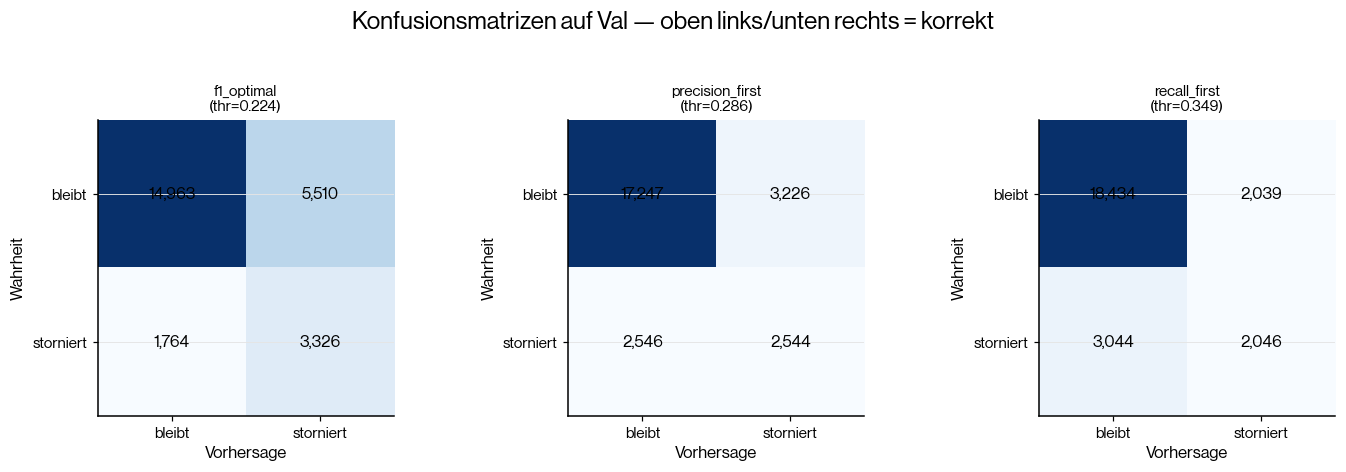

In [17]:
# =============================================================================
# §8b KONFUSIONSMATRIZEN — was bedeuten die Betriebspunkte konkret? (auf Val)
# =============================================================================
from sklearn.metrics import confusion_matrix

# Drei nebeneinanderliegende Panels, eins pro Betriebspunkt.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (_, row) in zip(axes, op_points.iterrows()):
    # Harte Ja/Nein-Entscheidung: Wahrscheinlichkeit >= Threshold?
    pred = (prob_val >= row["threshold"]).astype(int)
    # 2x2-Matrix: [[richtig-negativ, falsch-positiv], [falsch-negativ, richtig-positiv]].
    cm = confusion_matrix(y_val, pred)
    # Als Bild zeichnen, Zahlen in die Felder schreiben.
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="black", fontsize=11)
    ax.set_title(f"{row['name']}\n(thr={row['threshold']:.3f})", fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["bleibt", "storniert"])  # Vorhersage
    ax.set_yticks([0, 1]); ax.set_yticklabels(["bleibt", "storniert"])  # Wahrheit
    ax.set_xlabel("Vorhersage"); ax.set_ylabel("Wahrheit")
fig.suptitle("Konfusionsmatrizen auf Val — oben links/unten rechts = korrekt", y=1.05)
fig.tight_layout()
fig.savefig(FIG / "08_confusion_panel.png", dpi=150, bbox_inches="tight")
plt.show()

## §9 — Finale Bewertung auf Test (einmalig!)

Jetzt — und nur jetzt — öffnen wir den Tresor. Die Test-Buchungen (neueste 25 %) hat das
Modell nie gesehen, und keine Entscheidung wurde auf ihnen getroffen. Was hier rauskommt,
ist unsere ehrlichste Schätzung der Produktions-Performance.

Dazu drei Diagnose-Plots: **ROC** (Rangfolge), **PR-Kurve** (Präzision unter Schieflage),
**Kalibrierungskurve** (liegen vorhergesagte und echte Storno-Quoten aufeinander?).

== Headline (Test) ==
auc          0.7321
ap           0.4160
brier        0.1395
lift@5%      3.0854
lift@10%     2.5409
base_rate    0.1975

== Betriebspunkte auf Test ==
           name  threshold  precision  recall     f1
     f1_optimal     0.2243     0.3231  0.6488 0.4314
precision_first     0.2856     0.3914  0.4753 0.4293
   recall_first     0.3490     0.4408  0.3610 0.3970


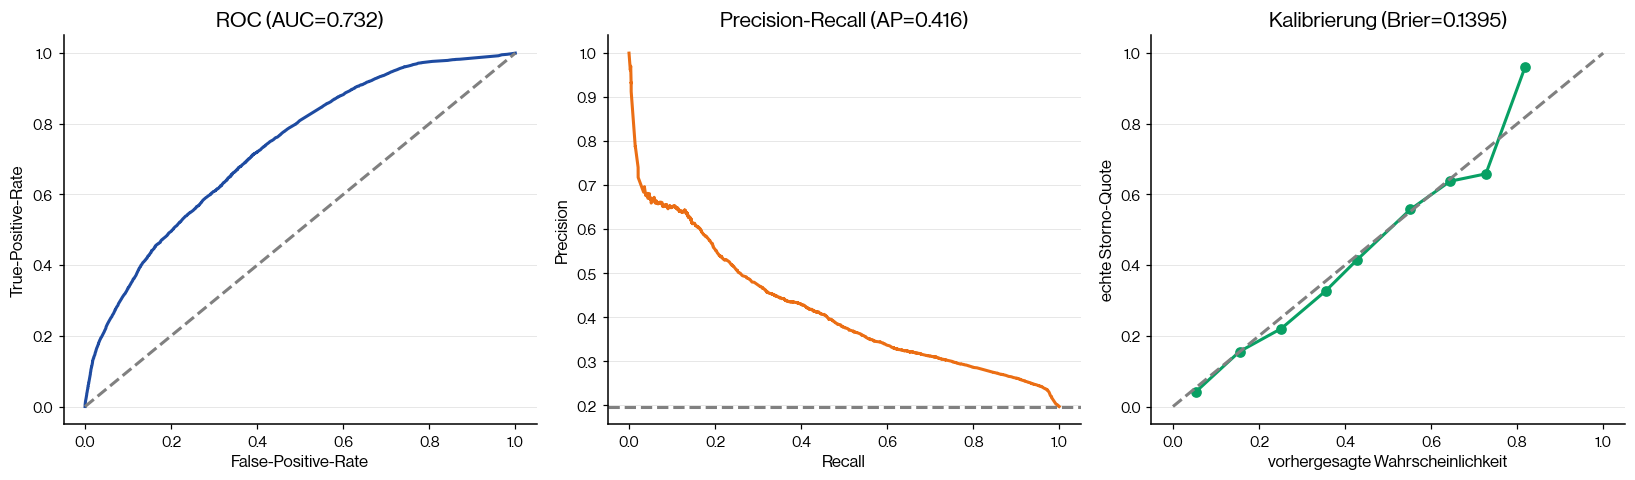

In [18]:
# =============================================================================
# §9 TEST-METRIKEN + DIAGNOSE-PLOTS
# =============================================================================
from sklearn.metrics import roc_curve, precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve

# Storno-Wahrscheinlichkeiten für die Test-Buchungen (erste und einzige Berührung!).
prob_test = model.predict_proba(X_test)[:, 1]

# Headline-Metriken auf Test — gleiche Definitionen wie in §7 auf Val.
test_metrics = pd.Series({
    "auc":      roc_auc_score(y_test, prob_test),
    "ap":       average_precision_score(y_test, prob_test),
    "brier":    brier_score_loss(y_test, prob_test),
    "lift@5%":  lift_at(y_test, prob_test, 0.05),
    "lift@10%": lift_at(y_test, prob_test, 0.10),
    "base_rate": float(y_test.mean()),
}, name="test").round(4)

# Zusätzlich: die drei auf VAL fixierten Thresholds auf Test anwenden.
# (Threshold wurde NICHT auf Test gewählt — wir prüfen nur, wie er sich schlägt.)
thr_rows = []
for _, row in op_points.iterrows():
    pred = (prob_test >= row["threshold"]).astype(int)        # harte Entscheidung
    thr_rows.append({"name": row["name"], "threshold": row["threshold"],
                     "precision": precision_score(y_test, pred),
                     "recall":    recall_score(y_test, pred),
                     "f1":        f1_score(y_test, pred)})
test_at_thresholds = pd.DataFrame(thr_rows).round(4)

# Beides speichern (Vergleichs-Notebook + Model Card greifen darauf zu).
test_metrics.to_csv(TAB / "test_metrics.csv")
test_at_thresholds.to_csv(TAB / "test_at_thresholds.csv", index=False)
print("== Headline (Test) ==");           print(test_metrics.to_string())
print("\n== Betriebspunkte auf Test =="); print(test_at_thresholds.to_string(index=False))

# --- Drei Diagnose-Plots nebeneinander ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (1) ROC-Kurve: Trefferquote gegen Fehlalarmquote über alle Thresholds.
fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, color=color("blue"))
axes[0].plot([0, 1], [0, 1], ls="--", color="grey")           # Diagonale = Münzwurf
axes[0].set_title(f"ROC (AUC={test_metrics['auc']:.3f})")
axes[0].set_xlabel("False-Positive-Rate"); axes[0].set_ylabel("True-Positive-Rate")

# (2) PR-Kurve: Präzision gegen Recall — aussagekräftiger bei 20% Positiven.
p2, r2, _ = precision_recall_curve(y_test, prob_test)
axes[1].plot(r2, p2, color=color("orange"))
axes[1].axhline(y_test.mean(), ls="--", color="grey")         # Basislinie = Storno-Quote
axes[1].set_title(f"Precision-Recall (AP={test_metrics['ap']:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

# (3) Kalibrierungskurve: vorhergesagte vs. tatsächliche Storno-Quote in 10 Eimern.
frac_pos, mean_pred = calibration_curve(y_test, prob_test, n_bins=10)
axes[2].plot(mean_pred, frac_pos, marker="o", color=color("green"))
axes[2].plot([0, 1], [0, 1], ls="--", color="grey")           # Ideal: exakt die Diagonale
axes[2].set_title(f"Kalibrierung (Brier={test_metrics['brier']:.4f})")
axes[2].set_xlabel("vorhergesagte Wahrscheinlichkeit"); axes[2].set_ylabel("echte Storno-Quote")

fig.tight_layout()
fig.savefig(FIG / "09_roc_pr_calibration.png", dpi=150)
plt.show()

## §10 — Slice-Analyse: Wo ist das Modell gut, wo schwach?

Eine Gesamt-AUC kann Schwächen verstecken. Fürs Overbooking entscheidend: Funktioniert
das Modell **pro Hotel** (dort wird die Overbooking-Entscheidung getroffen), pro Kanal
und pro Lead-Time? Gerade bei **neu eröffneten Häusern** mit wenig Historie ist hier
Vorsicht angesagt — kleine Stichprobe = unsichere AUC.

        slice                    group     n  cancel_rate    auc
property_name    Berlin Friedrichshain  3946       0.2347 0.7691
property_name   Bielefeld Hauptbahnhof  7415       0.1671 0.7213
property_name         Bochum Ehrenfeld  3247       0.1574 0.6929
property_name           Bremen Am Wall  5447       0.1996 0.7048
property_name        Cologne Ehrenfeld  2997       0.2019 0.7876
property_name             Cologne Sülz  1777       0.2116 0.8065
property_name  Frankfurt Sachsenhausen  4838       0.2702 0.8110
property_name         Fürth Hallstraße   464       0.2177 0.6860
property_name     Gütersloh Langer Weg  3127       0.1689 0.6856
property_name Osnabrück Johannisstraße  6320       0.1771 0.6867
property_name     Wolfsburg Schachtweg  2827       0.2041 0.6808
  channelCode                   Airbnb   989       0.1567 0.6560
  channelCode              Booking.com 19012       0.2355 0.7664
  channelCode                   Direct  3028       0.1139 0.7145
  channelCode            

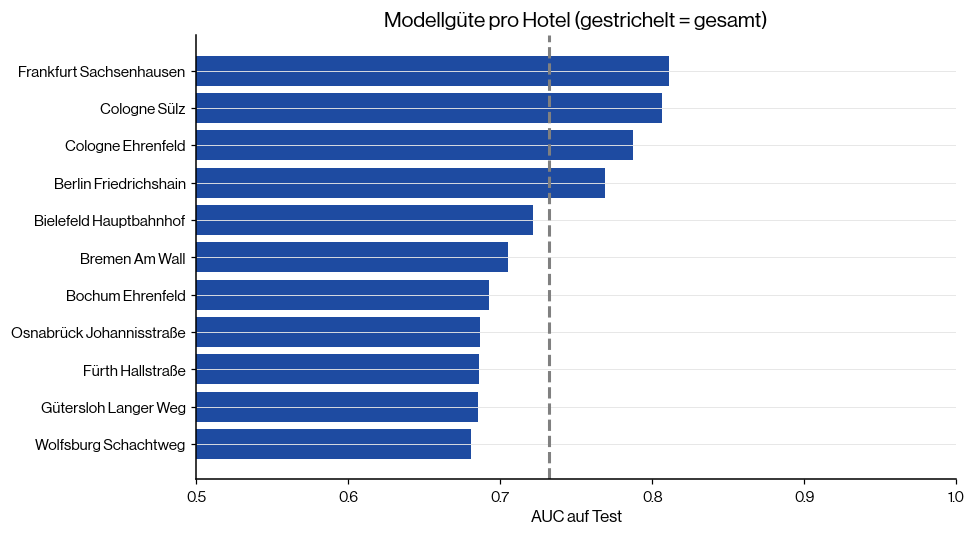

In [19]:
# =============================================================================
# §10 AUC JE SEGMENT (auf Test)
# =============================================================================
# Hilfstabelle: Test-Zeilen mit Wahrheit, Wahrscheinlichkeit und Slice-Spalten.
sl = df.loc[m_test, ["property_name", "channelCode", "lead_time_days"]].copy()
sl["y"], sl["p"] = y_test.values, prob_test

# Lead-Time in operative Eimer einteilen (0-7 Tage ist die kritische Zone).
sl["lead_bucket"] = pd.cut(sl["lead_time_days"], bins=[-1, 7, 30, 90, 10_000],
                           labels=["0-7d", "8-30d", "31-90d", "90d+"])

# AUC je Gruppe berechnen — nur wenn genug Zeilen UND beide Klassen vorhanden
# (sonst ist eine AUC mathematisch nicht definiert / nicht belastbar).
def slice_auc(frame, col, min_n=300):
    rows = []
    for g, grp in frame.groupby(col, observed=True):
        if len(grp) >= min_n and grp["y"].nunique() == 2:      # belastbar?
            rows.append({"slice": col, "group": str(g), "n": len(grp),
                         "cancel_rate": grp["y"].mean(),
                         "auc": roc_auc_score(grp["y"], grp["p"])})
    return pd.DataFrame(rows)

# Die drei wichtigsten Slices stapeln und speichern.
slices = pd.concat([slice_auc(sl, "property_name"),
                    slice_auc(sl, "channelCode"),
                    slice_auc(sl, "lead_bucket")]).round(4)
slices.to_csv(TAB / "slice_metrics.csv", index=False)
print(slices.to_string(index=False))

# --- Plot: AUC pro Hotel — die Overbooking-relevante Sicht --------------------
_prop = slices[slices["slice"] == "property_name"].sort_values("auc")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(_prop["group"], _prop["auc"], color=color("blue"))     # ein Balken pro Haus
ax.axvline(test_metrics["auc"], ls="--", color="grey")         # Linie = Gesamt-AUC
ax.set_xlim(0.5, 1.0)                                          # 0.5 = Münzwurf-Grenze
ax.set_xlabel("AUC auf Test"); ax.set_title("Modellgüte pro Hotel (gestrichelt = gesamt)")
fig.tight_layout()
fig.savefig(FIG / "10_auc_by_property.png", dpi=150)
plt.show()

## §11 — Explainability (XAI): *Warum* entscheidet das Modell so?

Vier Blickwinkel, vom billigsten zum teuersten:

1. **Koeffizienten** — der LogReg-Heimvorteil: Das Modell *ist* eine gewichtete Summe; die Gewichte sind die vollständige Erklärung. Positiv = treibt Richtung Storno.
2. **Permutation Importance** — Spalte durchmischen → wie stark fällt die AUC? Misst, worauf sich das Modell tatsächlich stützt (modellunabhängig).
3. **PDP/ICE** — Effektkurve eines Features: was passiert mit der Wahrscheinlichkeit, wenn man z.B. die Lead-Time durchspielt?
4. **SHAP** — zerlegt jede einzelne Vorhersage fair in Feature-Beiträge. Für lineare Modelle exakt und billig (`LinearExplainer`).

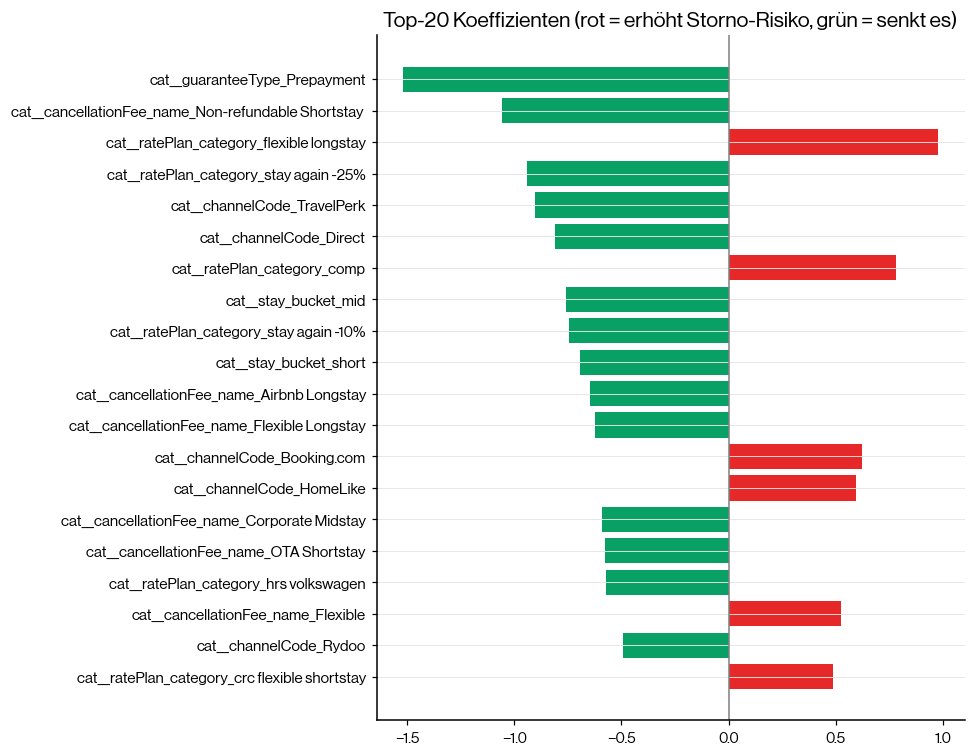

In [20]:
# =============================================================================
# §11a KOEFFIZIENTEN — die direkteste Erklärung der LogReg
# =============================================================================
# Die Kalibrier-Hülle hat 5 intern gefittete Basis-Modelle (eins pro Falte).
# Wir mitteln deren Koeffizienten — stabiler als ein einzelner Fit, kostet nichts.
_cals = model.named_steps["clf"].calibrated_classifiers_      # die 5 Kalibrier-Falten
_coefs = np.vstack([c.estimator.coef_.ravel() for c in _cals])  # 5 x n_spalten Gewichte
coef_mean = _coefs.mean(axis=0)                               # Mittelwert je Spalte
# Klarnamen der Modell-Spalten aus dem Preprocessor holen (z.B. "cat__channelCode_Booking.com").
feat_names = model.named_steps["prep"].get_feature_names_out()

# Tabelle bauen, nach Effektstärke (Betrag) sortieren, speichern.
coef_df = (pd.DataFrame({"feature": feat_names, "coef": coef_mean})
             .assign(abs_coef=lambda d: d["coef"].abs())
             .sort_values("abs_coef", ascending=False))
coef_df.to_csv(TAB / "coefficients.csv", index=False)

# Plot: Top 20 Treiber. Dank StandardScaler direkt vergleichbar:
# "+0.5" heißt grob: +1 Standardabweichung dieses Features erhöht die Storno-Logit um 0.5.
top = coef_df.head(20).iloc[::-1]                             # umdrehen: größter oben
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["coef"],                          # rot = Richtung Storno
        color=[color("red") if c > 0 else color("green") for c in top["coef"]])
ax.axvline(0, color="grey", lw=1)
ax.set_title("Top-20 Koeffizienten (rot = erhöht Storno-Risiko, grün = senkt es)")
fig.tight_layout()
fig.savefig(FIG / "11_coefficients.png", dpi=150)
plt.show()

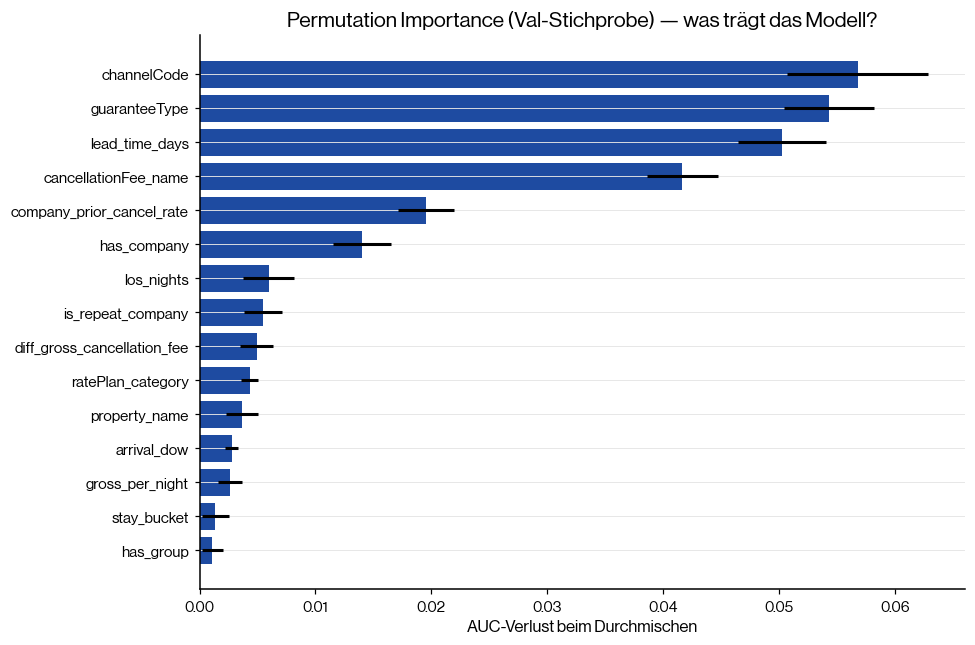

In [21]:
# =============================================================================
# §11b PERMUTATION IMPORTANCE — worauf stützt sich das Modell wirklich? (auf Val)
# =============================================================================
from sklearn.inspection import permutation_importance

# Stichprobe statt komplettem Val: 5.000 Zeilen reichen für ein stabiles Ranking
# und sparen massiv Zeit (jede Spalte wird n_repeats-mal durchgemischt + neu gescort!).
_n = min(5000, len(X_val))
Xs = X_val.sample(_n, random_state=SEED)                      # zufällige Val-Zeilen
ys = y_val.loc[Xs.index]                                      # passende Wahrheiten

# Jede ROH-Spalte (vor One-Hot) 5x durchmischen und den AUC-Verlust messen.
perm = permutation_importance(model, Xs, ys, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=-1)

# Ergebnis als sortierte Tabelle + speichern.
perm_df = (pd.DataFrame({"feature": FEATURES,
                         "auc_drop_mean": perm.importances_mean,
                         "auc_drop_std":  perm.importances_std})
             .sort_values("auc_drop_mean", ascending=False))
perm_df.to_csv(TAB / "permutation_importance.csv", index=False)

# Plot: Top 15 mit Unsicherheits-Balken (Streuung über die 5 Wiederholungen).
top = perm_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["auc_drop_mean"],
        xerr=top["auc_drop_std"], color=color("blue"))
ax.set_xlabel("AUC-Verlust beim Durchmischen")
ax.set_title("Permutation Importance (Val-Stichprobe) — was trägt das Modell?")
fig.tight_layout()
fig.savefig(FIG / "11_permutation_importance.png", dpi=150)
plt.show()

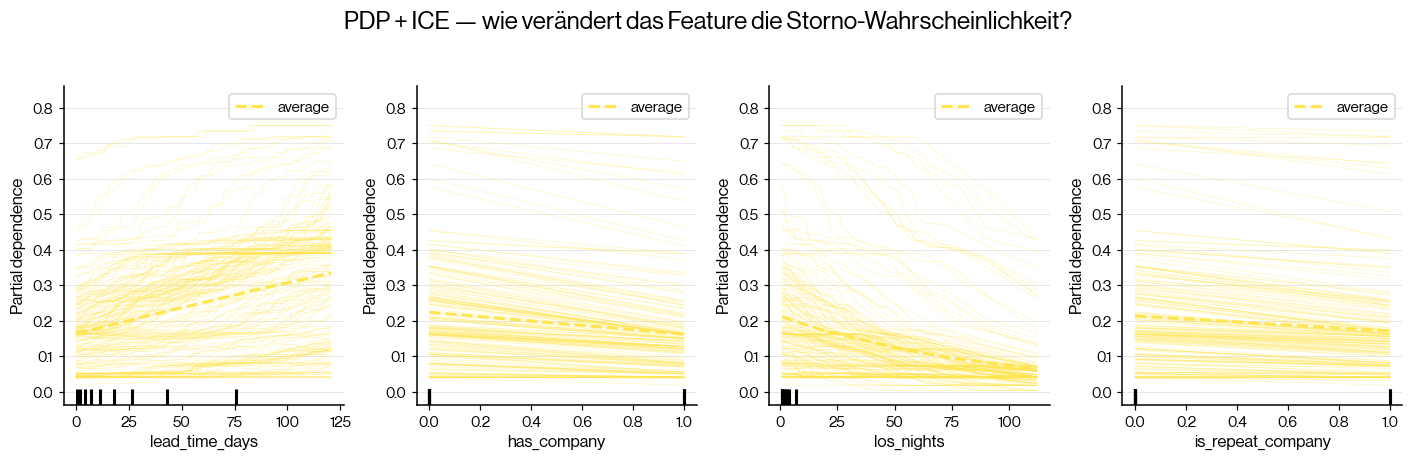

In [22]:
# =============================================================================
# §11c PDP + ICE — Effektkurven der wichtigsten numerischen Features
# =============================================================================
from sklearn.inspection import PartialDependenceDisplay

# Die 4 wichtigsten NUMERISCHEN Features laut Permutation Importance auswählen.
top_num = [f for f in perm_df["feature"] if f in NUM_FEATURES][:4]

# PDP (dicke Linie) = Durchschnittseffekt; ICE (dünne Linien) = Effekt je Einzelbuchung.
# Spreizen sich die ICE-Linien stark, wirkt das Feature je nach Kontext unterschiedlich.
fig, axes = plt.subplots(1, len(top_num), figsize=(13, 4))    # ein Panel pro Feature
PartialDependenceDisplay.from_estimator(
    model,                                  # die komplette Pipeline (inkl. Preprocessing)
    X_val.sample(min(1000, len(X_val)), random_state=SEED),  # 1000 Zeilen genügen
    features=top_num,                       # welche Features geplottet werden
    kind="both",                            # "both" = PDP + ICE zusammen
    subsample=200,                          # max. 200 ICE-Linien (Lesbarkeit)
    random_state=SEED,
    ax=axes,                                # unsere vorbereiteten Panels nutzen
)
fig.suptitle("PDP + ICE — wie verändert das Feature die Storno-Wahrscheinlichkeit?", y=1.04)
fig.tight_layout()
fig.savefig(FIG / "11_pdp_ice.png", dpi=150, bbox_inches="tight")
plt.show()

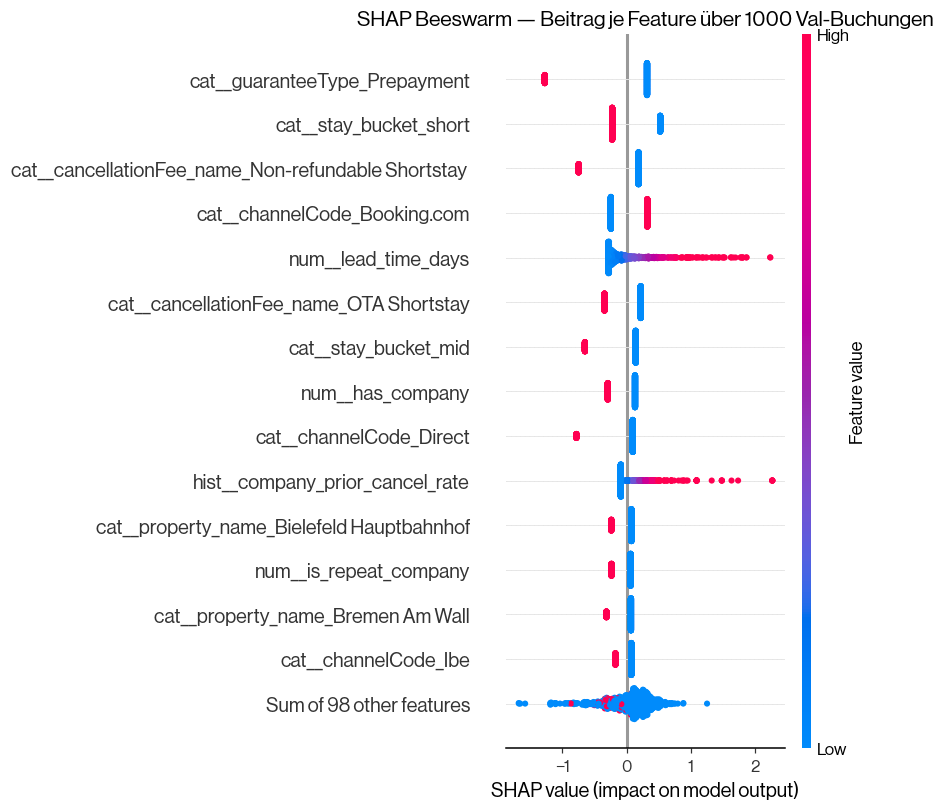

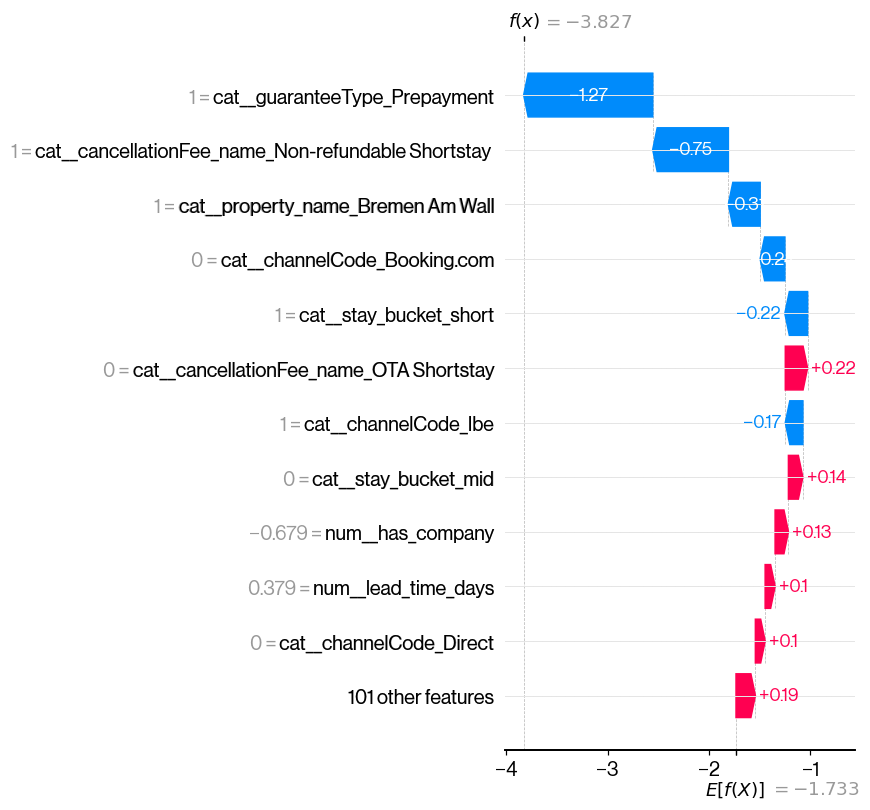

In [23]:
# =============================================================================
# §11d SHAP — faire Beitragszerlegung pro Buchung (exakt für lineare Modelle)
# =============================================================================
import shap

# Wir erklären das UNkalibrierte Basis-Modell der ersten Kalibrier-Falte:
# die Kalibrierung ist eine monotone Nachkorrektur und ändert nichts daran,
# WELCHE Features eine Buchung riskant machen. [Alternative: KernelExplainer
# auf der Gesamt-Pipeline — modellagnostisch, aber ~100x langsamer.]
_base = model.named_steps["clf"].calibrated_classifiers_[0].estimator

# SHAP braucht die fertig vorverarbeitete Zahlenmatrix (nach Imputing/Scaling/One-Hot).
_Xs   = X_val.sample(min(1000, len(X_val)), random_state=SEED)   # 1000 Val-Zeilen
_Xenc = model.named_steps["prep"].transform(_Xs)                  # durch den Preprocessor
# Sparse-Matrix in normale (dichte) umwandeln — bei 1000 Zeilen unproblematisch —
# und als DataFrame mit Klarnamen verpacken (so kennt SHAP die Feature-Namen).
_Xdense = np.asarray(_Xenc.todense()) if hasattr(_Xenc, "todense") else np.asarray(_Xenc)
_Xdf = pd.DataFrame(_Xdense, columns=list(feat_names))

# LinearExplainer: exakte SHAP-Werte für lineare Modelle, läuft in Sekunden.
explainer = shap.LinearExplainer(_base, _Xdf)
shap_values = explainer(_Xdf)

# Beeswarm: pro Feature ein Punktstreifen — Position = Beitrag, Farbe = Featurewert.
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Beitrag je Feature über 1000 Val-Buchungen")
plt.gcf().tight_layout()
plt.gcf().savefig(FIG / "11_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Waterfall: EINE einzelne Buchung komplett zerlegt — perfekt zum Erklären in der App.
shap.plots.waterfall(shap_values[0], max_display=12, show=False)
plt.gcf().tight_layout()
plt.gcf().savefig(FIG / "11_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## §12 — Artefakte speichern

Was andere Notebooks / die App später brauchen:

- **Modell** (`01_logreg_model.joblib`) — die komplette Pipeline (Preprocessing + kalibriertes Modell) in einer Datei
- **Predictions** (Val + Test) — fürs faire Vergleichs-Notebook (alle Modelle, exakt gleiche Zeilen)
- **Model Card** (JSON) — der Steckbrief: Datenfenster, Splits, Features, Hyperparameter, Metriken, Thresholds. Das ist unser Audit-Log.

In [24]:
# =============================================================================
# §12 PERSISTIEREN
# =============================================================================
# joblib = Standardweg, sklearn-Objekte auf Platte zu speichern.
import joblib
from src import data_dir
import sklearn

# (1) Die komplette Pipeline speichern — App/Scoring laden genau diese eine Datei.
joblib.dump(model, data_dir() / "01_logreg_model.joblib")

# (2) Val- und Test-Predictions mit Kontextspalten speichern (für Notebook 05).
# Val- und Test-Block GETRENNT bauen und dann stapeln — so ist die Zuordnung
# Zeile <-> Wahrscheinlichkeit garantiert korrekt (kein Verlass auf df-Reihenfolge).
_ctx = ["arrival", "property_name", "lead_time_days", "temporal_split"]
pred_val  = df.loc[m_val,  _ctx].copy()                       # Kontext der Val-Zeilen
pred_val["y_true"], pred_val["y_prob"]   = y_val.values,  prob_val   # Wahrheit + Score
pred_test = df.loc[m_test, _ctx].copy()                       # Kontext der Test-Zeilen
pred_test["y_true"], pred_test["y_prob"] = y_test.values, prob_test
pred = pd.concat([pred_val, pred_test])                       # untereinander stapeln
pred.to_parquet(data_dir() / "01_logreg_predictions.parquet")

# (3) Model Card: alles Wichtige als JSON — menschen- und maschinenlesbar.
model_card = {
    "model":            "logistic_regression_elasticnet_isotonic",
    "notebook":         "01_logreg.ipynb",
    "trained_at":       pd.Timestamp.now(tz="UTC").isoformat(),     # Zeitstempel
    "sklearn_version":  sklearn.__version__,                         # Reproduzierbarkeit
    "fast_dev":         FAST_DEV,                                    # war es ein Volllauf?
    "n_train":          int(len(X_train)),                           # Datenumfang
    "n_val":            int(len(X_val)),
    "n_test":           int(len(X_test)),
    "features_numeric": NUM_FEATURES + NUM_HISTORY,                  # vollständige Feature-Liste
    "features_categorical": CAT_FEATURES,
    "hyperparams":      {**LOGREG_FIXED, **FINAL_PARAMS, "calibration": "isotonic_cv5"},
    "tuning": {
        "selected":      "tuned" if FINAL_PARAMS is not BASE_PARAMS else "baseline",
        "search_n_iter": int(N_SEARCH),
        "best_cv_ap":    float(search.best_score_),
        "space":         "C ~ loguniform(1e-3, 1e2), l1_ratio ~ uniform(0, 1)",
    },
    "val_metrics":      val_metrics.to_dict(),                       # Val-Ergebnisse
    "test_metrics":     test_metrics.to_dict(),                      # Test-Ergebnisse
    "operating_points": op_points.to_dict(orient="records"),         # die 3 Thresholds
}
# JSON hübsch formatiert in den Tables-Ordner schreiben.
(TAB / "model_card.json").write_text(json.dumps(model_card, indent=2, default=str))

print("Gespeichert: Modell, Predictions (val+test), Model Card.")
print(f"Test-AUC = {test_metrics['auc']:.4f} | Brier = {test_metrics['brier']:.4f}")

Gespeichert: Modell, Predictions (val+test), Model Card.
Test-AUC = 0.7321 | Brier = 0.1395


## §13 — Fazit & offene Diskussionspunkte

*(Nach dem Volllauf ausfüllen / im Chat diskutieren.)*

**Ergebnis-Zusammenfassung:** Test-AUC ___ · AP ___ · Brier ___ · Lift@10% ___

**Offene Entscheidungen aus diesem Notebook:**

1. `ratePlan_category` (59) vs. `ratePlan_type` (6) — feiner vs. robuster (§2)
2. ~~`C` + `l1_ratio` ungetuned~~ → **getunt in §6b** (RandomizedSearch auf Zeit-CV, Baseline-vs-getunt auf Val; Ergebnis in `baseline_vs_tuned_val.csv`)
3. Kalibrierung: isotonic/cv=5 vs. sigmoid vs. FrozenEstimator-auf-Val (§5)
4. Threshold ökonomisch (€-Kosten) statt F1-basiert wählen (§8)
5. `company_prior_cancel_rate`: 0-Füllung vs. globale Quote als Füllwert (§2)
6. Feinheit Company-History: Outcomes früherer Buchungen können zum Buchungszeitpunkt
   z.T. noch ungelöst gewesen sein (mildes Lookahead, in 00 §5.2 dokumentiert) — für
   Produktion unkritisch, da beim Scoring nur aufgelöste Historie verfügbar ist

**Nächster Schritt:** Dieses Notebook ist das Template — 02 (XGBoost) und 03 (HistGB)
ersetzen nur §5 (Modelldefinition) und §11a (Koeffizienten → Gain/SHAP-Importances).

## §13 Walk-forward evaluation + deployment model (v11)

Routes the production model + honest forward metrics through `src.training` (same code the app's retrain calls). `mode="retune"` re-searches hyperparameters; the app uses `mode="refit"`. Heavy — several minutes.

In [ ]:
# Walk-forward eval + DEPLOYMENT fit via src.training (same path the app calls).
import src.training as T
MODEL = "logreg"
deploy = T.retrain(MODEL, mode="retune")
import pandas as pd
display(pd.DataFrame(deploy["walk_forward"]["per_fold"]))
print("walk-forward aggregate (mean ± std):")
for _m,_v in deploy["walk_forward"]["aggregate"].items():
    print(f"  {_m:6s} {_v['mean']:.4f} ± {_v['std']:.4f}")
print("\ndeployment model persisted ->", deploy["persisted"]["joblib"])
print("trained on", deploy["n_train_deploy"], "rows | feature_change:", deploy["feature_change"]["changed"])